# IMPORTING NECESSARY PACKAGES

In [1]:
import pandas as pd
import numpy as np

# Data Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Data Pre-Processing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Train-Test Splitting and Hyperparameter Tuning
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# Models
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, AdaBoostRegressor, VotingRegressor, StackingRegressor
from sklearn.neural_network import MLPRegressor

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/sample_submission.csv
/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/train.csv
/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/test.csv


In [3]:
train_df = pd.read_csv("/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/mlp-may-2026-kaggle-assignment-1/test.csv")

In [4]:
train_df.head()

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left,price
0,0,Vistara,UK-930,Mumbai,Early_Morning,one,Night,Chennai,Business,NaN,40.0,64173
1,1,Air_India,AI-539,Chennai,Evening,one,Morning,Mumbai,Economy,16.08,26.0,4357
2,2,SpiceJet,SG-8107,Delhi,Early_Morning,zero,Morning,Chennai,Economy,2.92,25.0,3251
3,3,NaN,0.00E+00,Hyderabad,Early_Morning,zero,Morning,Bangalore,Economy,1.50,22.0,1776
4,4,Air_India,AI-569,Chennai,Early_Morning,one,Morning,Bangalore,Economy,4.83,20.0,3584


In [5]:
test_df.head()

,id,airline,flight,source,departure,stops,arrival,destination,class,duration,days_left
0,0,Vistara,UK-816,Bangalore,Morning,zero,Afternoon,Delhi,Economy,2.67,18.0
1,1,Air_India,AI-440,Chennai,Early_Morning,zero,Morning,Delhi,Economy,NaN,5.0
2,2,SpiceJet,SG-8938,Delhi,Evening,one,Evening,Bangalore,Economy,NaN,44.0
3,3,Vistara,UK-838,Chennai,Night,one,Evening,Kolkata,Business,21.00,26.0
4,4,Air_India,AI-429,Delhi,Morning,one,Evening,Mumbai,Business,7.25,22.0


In [6]:
X_train = train_df.drop('price', axis = 1) # Dropping a column
y_train = train_df['price']

X_test = test_df

# Baseline (Dummy) Model

In [7]:
dummy_model = DummyRegressor().fit(X_train, y_train)
dummy_pred = dummy_model.predict(X_test)

# Inspection Tasks

## 1. Data Types of Columns

In [8]:
print(train_df.dtypes)

id               int64
airline         object
flight          object
source          object
departure       object
stops           object
arrival         object
destination     object
class           object
duration       float64
days_left      float64
price            int64
dtype: object


## 2. Descriptive Statistics of Numerical Columns

In [9]:
print(train_df.describe())

                id      duration     days_left         price
count  40000.00000  36987.000000  35562.000000   40000.00000
mean   19999.50000     12.004088     26.197936   20801.49025
std    11547.14972      7.108063     13.469232   22729.14842
min        0.00000      0.830000      1.000000    1105.00000
25%     9999.75000      6.670000     15.000000    4687.00000
50%    19999.50000     11.080000     26.000000    7353.00000
75%    29999.25000     15.920000     38.000000   42521.00000
max    39999.00000     47.080000     49.000000  114704.00000


## 3. Identifying and Handling Missing Values

In [10]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           40000 non-null  int64  
 1   airline      35387 non-null  object 
 2   flight       40000 non-null  object 
 3   source       40000 non-null  object 
 4   departure    35208 non-null  object 
 5   stops        37681 non-null  object 
 6   arrival      40000 non-null  object 
 7   destination  40000 non-null  object 
 8   class        40000 non-null  object 
 9   duration     36987 non-null  float64
 10  days_left    35562 non-null  float64
 11  price        40000 non-null  int64  
dtypes: float64(2), int64(2), object(8)
memory usage: 3.7+ MB
None


There are 40000 samples. 

There are missing values in the features - **airline**, **departure**, **stops**, **duration**, and **days_left**.

These will be **imputed**, but not now. Outliers and duplicates can play a role in skewing statistics.

In [11]:
train_df.isna().sum().sum()

np.int64(19175)

There are 19,175 total missing values.

## 4. Identifying and Handling Duplicates

In [12]:
# First, remove the id column (which uniquely identifies each sample)
# This DataFrame is used.

train_df_without_id = train_df.drop('id', axis = 1)

In [13]:
# Check for duplicates (present)
print(train_df_without_id.duplicated().sum())

250


In [14]:
# Now, drop duplicates.
train_df_without_id.drop_duplicates(inplace = True)

## 5. Identifying and Handling Outliers

In [15]:
numerical_features = {'duration', 'days_left'}

outlier_count_by_feature = {}

for feature in numerical_features:
    q1 = train_df_without_id[feature].quantile(0.25)
    q3 = train_df_without_id[feature].quantile(0.75)
    iqr = q3 - q1

    lower_criteria = (train_df_without_id[feature] < (q1 - 1.5 * iqr))
    upper_criteria = (train_df_without_id[feature] > (q3 + 1.5 * iqr))
    outliers = (train_df_without_id.loc[lower_criteria | upper_criteria])

    outlier_count_by_feature[feature] = len(outliers)

print(outlier_count_by_feature)
    

{'duration': 229, 'days_left': 0}


##### While the duration feature has several extreme values (>30 hours), they may reflect journeys with longer layovers, rather than data-entry errors. Since such itineraries influence costs, the samples are retained.

# Exploratory Data Analysis (visualisations)

## 1. Histogram Plots for Distribution of Numeric Features

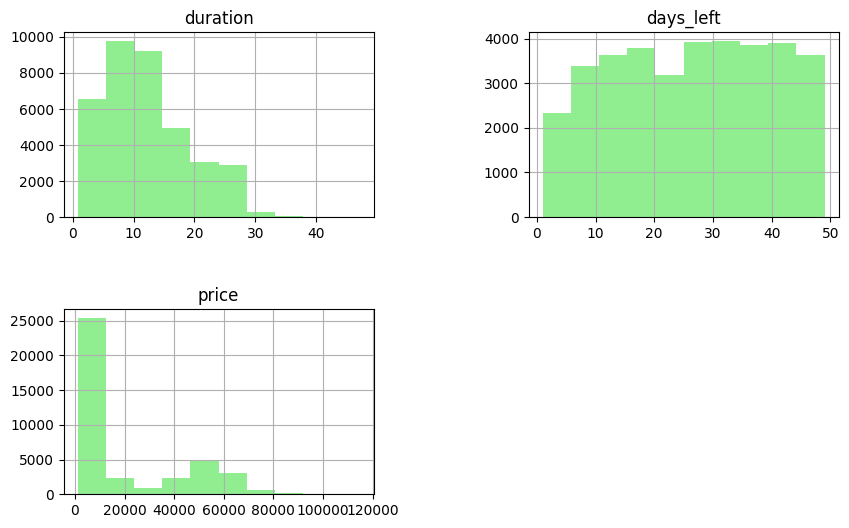

In [16]:
train_df_without_id.hist(bins = 10, color = 'lightgreen', figsize = (10, 6))

plt.subplots_adjust(hspace = 0.5, wspace = 0.5)
plt.show()

Based on the visualisation,

- Most durations are under 20 hours
- There is an even spread for the **days_left** feature, ranging up to 50 days.
- Most prices are less than 15000.

## 2. Heatmaps on Numerical Features (to show extents of correlation)

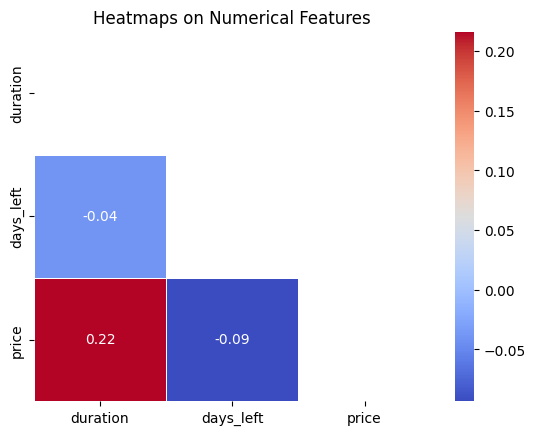

In [17]:
correlations = train_df_without_id[['duration', 'days_left', 'price']].corr()
mask = np.triu(np.ones_like(correlations, dtype = bool))
sns.heatmap(correlations, cmap = 'coolwarm', linewidths = 0.5, cbar = True, annot = True, fmt = '.2f', mask = mask)

plt.title("Heatmaps on Numerical Features")
plt.show()

Based on the visualisation, 

- The only instance of positive correlation with price occurs with the **duration** feature
- The same correlation is of the **highest** degree between any two numerical features

## 3. Price vs Airline 

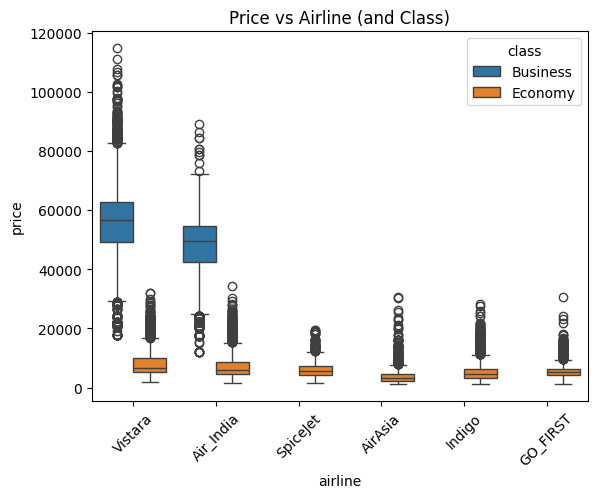

In [18]:
sns.boxplot(data = train_df_without_id, x = 'airline', y = 'price', hue = 'class')

plt.xticks(rotation = 45)
plt.title("Price vs Airline (and Class)")
plt.show()

Based on the visualisation,

- Only Vistara and Air_India provide Business class.
- By comparing medians, AirAsia has the lowest prices.
- By comparing medians, Vistara has the highest prices for both Economy and Business class. 

## 4. Market Share across Airlines

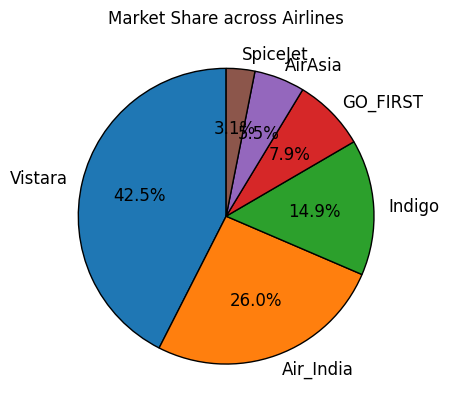

In [19]:
airline_counts = train_df_without_id["airline"].value_counts()

plt.pie(airline_counts.values, labels = airline_counts.index, autopct = '%1.1f%%', startangle = 90, textprops = {'fontsize': 12}, wedgeprops = {'edgecolor': 'black'})
plt.title('Market Share across Airlines')
plt.show()

Based on the visualisation,

- Vistara captures the largest market share, even though it is the most expensive one.
- Vistara, Air_India, and Indigo together capture more than 75% of the market share.
- While SpiceJet had the cheapest fares, its market share is the lowest of all airlines.

# Pre-Processing

In [20]:
# The flight feature is also largely irrelevant for predicting price.

X, y = train_df_without_id.drop(["price", "flight"], axis = 1), train_df_without_id["price"]

## 1. Imputation

- Categorical features will have missing values imputed using the **most_frequent** strategy.
- Numerical features will have missing values imputed using the **median** strategy.

In [21]:
imputer = ColumnTransformer(transformers = [
                            ("categoricalImputer", SimpleImputer(strategy = "most_frequent"), ['departure', 'airline', 'stops']),
                            ("numericalImputer", SimpleImputer(strategy = "median"), ['days_left', 'duration'])
                            ], remainder = 'passthrough', verbose_feature_names_out = False, force_int_remainder_cols=False
                           ).set_output(transform = 'pandas')

## 2. Encoding Categorical Features

- Categorical features are encoded using the OneHotEncoder

In [22]:
encoder = ColumnTransformer(transformers = [
                            ("oneHot", OneHotEncoder(drop = 'first', sparse_output = False, handle_unknown = 'ignore'), ['airline', 'source', 'departure', 'stops', 'arrival', 'class', 'destination'])
                            ], remainder = 'passthrough', verbose_feature_names_out = False, force_int_remainder_cols=False
                           ).set_output(transform = 'pandas')

## 3. Scaling Numerical Features

- Numerical features are scaled using the StandardScaler

In [23]:
scaler = ColumnTransformer(transformers = [
                            ("standardScaler", StandardScaler(), ['days_left', 'duration'])
                            ], remainder = 'passthrough', verbose_feature_names_out = False, force_int_remainder_cols=False
                          ).set_output(transform = 'pandas')

In [24]:
pre_pipeline = Pipeline(steps = [
    ("Imputation", imputer),
    ("Encoding", encoder),
    ("Scaling", scaler)
]).set_output(transform = 'pandas')

pre_pipeline

Pipeline(steps=[('Imputation',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('categoricalImputer',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['departure', 'airline',
                                                   'stops']),
                                                 ('numericalImputer',
                                                  SimpleImputer(strategy='median'),
                                                  ['days_left', 'duration'])],
                                   verbose_feature_names_out=False)),
                ('Encoding',
                 ColumnTransf...
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['airline', 'source',
                                                   'departure', 'stops',
                                                   'arrival', 'class',
                                                   'destination'])],
                                   verbose_feature_names_out=False)),
                ('Scaling',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('standardScaler',
                                                  StandardScaler(),
                                                  ['days_left', 'duration'])],
                                   verbose_feature_names_out=False))])

# Train-Validation Set Split and Pipeline Application

In [25]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.3, random_state = 42)

X_train_processed = pre_pipeline.fit_transform(X_train)
X_val_processed = pre_pipeline.transform(X_val)

# Model Training and Performance Analysis

## 1. Linear Regression

In [26]:
lr_model = LinearRegression()
lr_model.fit(X_train_processed, y_train)
lr_score = lr_model.score(X_val_processed, y_val)

## 2. SGD Regression

In [27]:
sgd_model = SGDRegressor()
sgd_model.fit(X_train_processed, y_train)
sgd_score = sgd_model.score(X_val_processed, y_val)

## 3. LASSO Regression

In [28]:
lasso_model = Lasso()
lasso_model.fit(X_train_processed, y_train)
lasso_score = lasso_model.score(X_val_processed, y_val)

## 4. Ridge Regression

In [29]:
ridge_model = Ridge()
ridge_model.fit(X_train_processed, y_train)
ridge_score = ridge_model.score(X_val_processed, y_val)

## 5. K Neighbors Regression (5 neighbors)

In [30]:
kn_reg_model = KNeighborsRegressor(n_neighbors = 5)
kn_reg_model.fit(X_train_processed, y_train)
kn_reg_score = kn_reg_model.score(X_val_processed, y_val)

## 6. Support Vector Regression

In [31]:
svr_model = SVR()
svr_model.fit(X_train_processed, y_train)
svr_score = svr_model.score(X_val_processed, y_val)

## 7. Decision Tree Regression

In [32]:
dt_reg_model = DecisionTreeRegressor(random_state = 42)
dt_reg_model.fit(X_train_processed, y_train)
dt_score = dt_reg_model.score(X_val_processed, y_val)

## 8. Bagging Regression

In [33]:
bag_reg_model = BaggingRegressor(random_state = 42)
bag_reg_model.fit(X_train_processed, y_train)
bag_score = bag_reg_model.score(X_val_processed, y_val)

## 9. AdaBoost Regression

In [34]:
adaBoost_reg_model = AdaBoostRegressor(random_state = 42)
adaBoost_reg_model.fit(X_train_processed, y_train)
boost_score = adaBoost_reg_model.score(X_val_processed, y_val)

## 10. Random Forest Regression

In [35]:
randomForest_reg_model = RandomForestRegressor(random_state = 42)
randomForest_reg_model.fit(X_train_processed, y_train)
rf_score = randomForest_reg_model.score(X_val_processed, y_val)

## 11. Neural Network (MLP) Regression

In [36]:
mlp_reg_model = MLPRegressor(random_state = 42)
mlp_reg_model.fit(X_train_processed, y_train)
mlp_score = mlp_reg_model.score(X_val_processed, y_val)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


{'Linear': 0.9054968357605306, 'SGD': 0.9055327715726431, 'LASSO': 0.9054856047578616, 'Ridge': 0.9054962487983108, 'KNeighbors': 0.8872272380231204, 'SVR': -0.330912099377332, 'DT': 0.9392018865445082, 'Bagging': 0.9644473084945875, 'Boosting': 0.9264477608911986, 'Random Forest': 0.9665925014639845, 'MLP': 0.8930951262331461}


Text(0.5, 1.0, 'R2 Score vs Model on Validation Set')

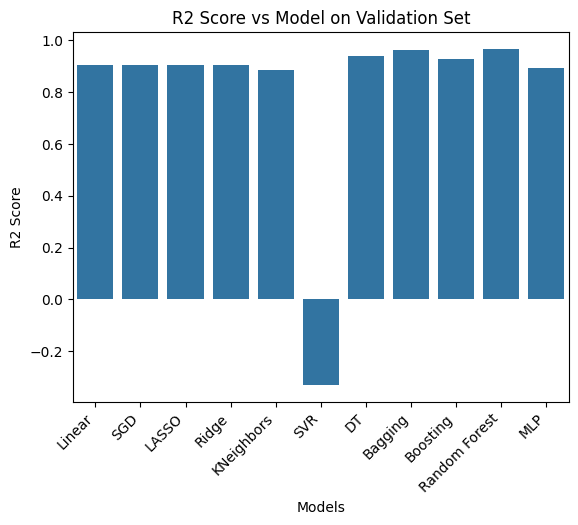

In [37]:
models = ["Linear", "SGD", "LASSO", "Ridge", "KNeighbors", "SVR", "DT", "Bagging", "Boosting", "Random Forest", "MLP"]
scores = [lr_score, sgd_score, lasso_score, ridge_score, kn_reg_score, svr_score, dt_score, bag_score, boost_score, rf_score, mlp_score]

print(dict(zip(models, scores)))

sns.barplot(x = models, y = scores)
plt.xlabel("Models")
plt.xticks(rotation = 45, ha = 'right')
plt.ylabel("R2 Score")
plt.title("R2 Score vs Model on Validation Set")

From the scores, we can conclude that the three best-performing models on the validation set were:-

- Random Forest Regressor
- Bagging Regressor
- Decision Tree Regressor

# Hyperparameter Tuning

We will perform hyperparameter tuning on the three best-performing models.

For the sake of speed on large datasets, we will use RandomizedSearchCV

## 1. Decision Tree Regressor

In [38]:
param_grid_dt = {
    'max_depth': [None] + list(range(5, 51, 5)),
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
}

In [39]:
new_dt = RandomizedSearchCV(dt_reg_model, param_grid_dt, cv = 5, n_jobs = -1, random_state = 42, n_iter = 10)
new_dt.fit(X_train_processed, y_train)
new_dt_score = new_dt.score(X_val_processed, y_val)

new_dt_score

0.953948357529034

## 2. Bagging Regressor

In [40]:
param_grid_bag = {
    "n_estimators": [x for x in range(10, 201, 10)],
    "max_samples": [0.4, 0.5, 0.6, 0.8, 1.0],
    "max_features": [0.4, 0.6, 0.8, 1.0],
    "bootstrap": [True, False]
}

In [41]:
new_bag = RandomizedSearchCV(bag_reg_model, param_grid_bag, cv = 5, n_jobs = -1, random_state = 42, n_iter = 10)
new_bag.fit(X_train_processed, y_train)
new_bag_score = new_bag.score(X_val_processed, y_val)

new_bag_score

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


0.9662071984624404

## 3. Random Forest Regressor

In [42]:
param_grid_rf = {
    "n_estimators": [x for x in range(50, 301, 25)],
    "max_depth": [None] + list(range(5, 51, 5)),
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
}

In [43]:
new_rf = RandomizedSearchCV(randomForest_reg_model, param_grid_rf, cv = 5, n_jobs = -1, random_state = 42, n_iter = 10)
new_rf.fit(X_train_processed, y_train)
new_rf_score = new_rf.score(X_val_processed, y_val)

new_rf_score

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


0.9665957713643571

# Voting and Stacking Regressors

This is a final technique for achieving the best performance

## Voting Regressor

In [44]:
vote = VotingRegressor([("dt", new_dt),
                        ("bag", new_bag),
                        ("rf", new_rf)
                        ])

vote.fit(X_train_processed, y_train)
vote_score = vote.score(X_val_processed, y_val)

vote_score

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


0.9648980071208552

## Stacking Regressor

In [ ]:
stack = StackingRegressor([("dt", new_dt),
                        ("bag", new_bag),
                        ("rf", new_rf)
                        ])

stack.fit(X_train_processed, y_train)
stack_score = stack.score(X_val_processed, y_val)

stack_score

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


# Deciding the Best Model

In [ ]:
models = {
    "Decision Tree (Tuned)": new_dt.best_estimator_,
    "Bagging (Tuned)": new_bag.best_estimator_,
    "Random Forest (Tuned)": new_rf.best_estimator_,
    "Voting Regressor": vote,
    "Stacking Regressor": stack
}

scores = {
    "Decision Tree (Tuned)": new_dt_score,
    "Bagging (Tuned)": new_bag_score,
    "Random Forest (Tuned)": new_rf_score,
    "Voting Regressor": vote_score,
    "Stacking Regressor": stack_score
}

best_model_name = max(scores, key = scores.get)
best_model = models[best_model_name]
print(f"Best model: {best_model_name}")

best_score = scores[best_model_name]
print(f"Validation R²: {best_score:.4f}")

# Final Submission

In [ ]:
test_df_without_id = test_df.drop(['id', 'flight'], axis = 1)
X_test_processed = pre_pipeline.transform(test_df_without_id)

pred = best_model.predict(X_test_processed)
submission = pd.DataFrame({'id': range(X_test_processed.shape[0]),
                           'target': pred
})


submission.to_csv('submission.csv', index = False)